# 실습

상환 여부를 예측하기 위한 로지스틱 회귀분석을 실시하고 결과를 해석하라.

분석 절차: 
* [데이터 구성하기](#데이터-구성하기)
* [로지스틱 회귀모델 및 회귀계수 검토](#로지스틱-회귀모델-및-회귀계수-검토)
* [예측 및 성능 평가](#예측-및-성능-평가)
* [결론 도출](#결론-도출)

#### 패키지 불러오기

In [18]:
# 데이터 구성:Series, DataFrame
import pandas as pd
# 행렬 연산
import numpy as np
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib
# scaling
from sklearn.preprocessing import StandardScaler
# 데이터 분할:train, test
from sklearn.model_selection import train_test_split
# 로지스틱 회귀
from statsmodels.api import Logit

# 분류모델 평가 함수
from sklearn.metrics import accuracy_score, f1_score 
from sklearn.metrics import confusion_matrix, classification_report

import os
os.chdir("/home/piai/Desktop/git/2. Big Data 분석")

#### 그래프 옵션 지정

In [19]:
# 그래프 한글폰트 적용:맑은 고딕
matplotlib.rc("font", family = "NanumSquare")
# 그래프 (-) 기호 표시
matplotlib.rc("axes", unicode_minus = False)

## 데이터 구성하기

#### 데이터 불러오기

In [20]:
df_raw = pd.read_csv("통신고객이탈.csv" , engine = "python")
df_raw.head()

,CHURN,CUSTOMER_ID,GENDER,AGE,CHARGE_TYPE,HANDSET,USAGE_BAND,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME
0,Active,K102990,F,31,CAT 100,ASAD170,Med,33.33,6,218,379.8,9,21.6,366,632.4
1,Active,K103280,M,27,CAT 100,S50,Med,30.87,10,373,656.4,11,28.0,411,810.4
2,Active,K103660,M,27,CAT 100,ASAD170,Med,49.40,11,260,582.0,0,0.0,265,614.1
3,Active,K103730,M,61,CAT 100,ASAD170,Med,48.60,1,294,661.8,14,101.5,326,844.0
4,Active,K104560,F,52,CAT 100,S50,Med,56.03,0,221,555.6,7,25.0,274,673.0


In [21]:
# Data 확인
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CHURN               930 non-null    object 
 1   CUSTOMER_ID         930 non-null    object 
 2   GENDER              930 non-null    object 
 3   AGE                 930 non-null    int64  
 4   CHARGE_TYPE         930 non-null    object 
 5   HANDSET             930 non-null    object 
 6   USAGE_BAND          930 non-null    object 
 7   SERVICE_DURATION    930 non-null    float64
 8   DROPPED_CALLS       930 non-null    int64  
 9   PEAK_CALLS_NO       930 non-null    int64  
 10  PEAK_CALLS_TIME     930 non-null    float64
 11  WEEKEND_CALLS_NO    930 non-null    int64  
 12  WEEKEND_CALLS_TIME  930 non-null    float64
 13  TOTAL_CALLS_NO      930 non-null    int64  
 14  TOTAL_CALLS_TIME    930 non-null    float64
dtypes: float64(4), int64(5), object(6)
memory usage: 109.1+ K

In [22]:
# Data 확인
print("Data 구조:", df_raw.shape)
print()
print("변수 : ", df_raw.columns)

Data 구조: (930, 15)

변수 :  Index(['CHURN', 'CUSTOMER_ID', 'GENDER', 'AGE', 'CHARGE_TYPE', 'HANDSET',
       'USAGE_BAND', 'SERVICE_DURATION', 'DROPPED_CALLS', 'PEAK_CALLS_NO',
       'PEAK_CALLS_TIME', 'WEEKEND_CALLS_NO', 'WEEKEND_CALLS_TIME',
       'TOTAL_CALLS_NO', 'TOTAL_CALLS_TIME'],
      dtype='object')


## 데이터 전처리

#### 결측값 처리

In [23]:
# 결측값 확인 -> 처리 불필요
df_raw.isnull().sum(axis = 0)

CHURN                 0
CUSTOMER_ID           0
GENDER                0
AGE                   0
CHARGE_TYPE           0
HANDSET               0
USAGE_BAND            0
SERVICE_DURATION      0
DROPPED_CALLS         0
PEAK_CALLS_NO         0
PEAK_CALLS_TIME       0
WEEKEND_CALLS_NO      0
WEEKEND_CALLS_TIME    0
TOTAL_CALLS_NO        0
TOTAL_CALLS_TIME      0
dtype: int64

#### 참조:범주형 변수 수준 확인

* CUSTOMER_ID (930)는 분석 제외

In [24]:
# 명목형 변수 목록
obj_cols = df_raw.select_dtypes("object").columns

for col in obj_cols:
    _n = len(df_raw[col].value_counts())
    print(col, ":", str(_n))

CHURN : 2
CUSTOMER_ID : 930
GENDER : 2
CHARGE_TYPE : 5
HANDSET : 11
USAGE_BAND : 6


In [25]:
# CHURN 변수:로지스틱 회귀는 목표변수가 반드시 1/0 정수형이어야 함
df_raw["CHURN"] = np.where(df_raw["CHURN"] == "Active", 0, 1)
df_raw.head()

,CHURN,CUSTOMER_ID,GENDER,AGE,CHARGE_TYPE,HANDSET,USAGE_BAND,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME
0,0,K102990,F,31,CAT 100,ASAD170,Med,33.33,6,218,379.8,9,21.6,366,632.4
1,0,K103280,M,27,CAT 100,S50,Med,30.87,10,373,656.4,11,28.0,411,810.4
2,0,K103660,M,27,CAT 100,ASAD170,Med,49.40,11,260,582.0,0,0.0,265,614.1
3,0,K103730,M,61,CAT 100,ASAD170,Med,48.60,1,294,661.8,14,101.5,326,844.0
4,0,K104560,F,52,CAT 100,S50,Med,56.03,0,221,555.6,7,25.0,274,673.0


In [26]:
df_raw.dtypes

CHURN                   int64
CUSTOMER_ID            object
GENDER                 object
AGE                     int64
CHARGE_TYPE            object
HANDSET                object
USAGE_BAND             object
SERVICE_DURATION      float64
DROPPED_CALLS           int64
PEAK_CALLS_NO           int64
PEAK_CALLS_TIME       float64
WEEKEND_CALLS_NO        int64
WEEKEND_CALLS_TIME    float64
TOTAL_CALLS_NO          int64
TOTAL_CALLS_TIME      float64
dtype: object

#### 데이터 분할

In [27]:
df_train, df_test = train_test_split(df_raw, test_size = 0.3, random_state = 1234)

print("train data shape: ", df_train.shape)
print("test data shape: ", df_test.shape)

train data shape:  (651, 15)
test data shape:  (279, 15)


## 로지스틱 회귀모델 및 회귀계수 검토

In [28]:
# from_formula 함수를 이용하여 변수 역할 지정
log_model = Logit.from_formula("""CHURN ~ C(GENDER) + AGE + C(CHARGE_TYPE) + C(HANDSET) + C(USAGE_BAND) + SERVICE_DURATION +
                                            DROPPED_CALLS + PEAK_CALLS_NO + PEAK_CALLS_TIME + WEEKEND_CALLS_NO + WEEKEND_CALLS_TIME +
                                            TOTAL_CALLS_NO + TOTAL_CALLS_TIME""", df_train)
# 적합
log_result = log_model.fit()
# 결과 출력
print(log_result.summary())

         Current function value: 0.253230
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                  CHURN   No. Observations:                  651
Model:                          Logit   Df Residuals:                      621
Method:                           MLE   Df Model:                           29
Date:                Fri, 31 Oct 2025   Pseudo R-squ.:                  0.5059
Time:                        00:50:07   Log-Likelihood:                -164.85
converged:                      False   LL-Null:                       -333.64
Covariance Type:            nonrobust   LLR p-value:                 2.736e-54
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                    -24.1057   2065.471     -0.012      0.991   -4072.354    4024.142
C(GENDER)[T.M]   

/home/piai/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [29]:
# 회귀계수가 유의한 변수만 사용한 모델
# 회귀계수 유의성 기준 제외변수(0.2 기준):GENDER,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO 등
log_model = Logit.from_formula("""CHURN ~ AGE + C(CHARGE_TYPE) + C(HANDSET) + C(USAGE_BAND) + SERVICE_DURATION +
                                DROPPED_CALLS + PEAK_CALLS_TIME """, df_train)
# 적합
log_result = log_model.fit()
# 결과 출력
print(log_result.summary())

         Current function value: 0.256192
         Iterations: 35


/home/piai/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:                  CHURN   No. Observations:                  651
Model:                          Logit   Df Residuals:                      627
Method:                           MLE   Df Model:                           23
Date:                Fri, 31 Oct 2025   Pseudo R-squ.:                  0.5001
Time:                        00:50:07   Log-Likelihood:                -166.78
converged:                      False   LL-Null:                       -333.64
Covariance Type:            nonrobust   LLR p-value:                 6.611e-57
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                    -26.3297   1.31e+04     -0.002      0.998   -2.57e+04    2.57e+04
C(CHARGE_TYPE)[T.CAT 200]     -0.8151      0.576     -1.415      0.157      -1.944 

## 예측 및 성능 평가

#### 예측 및 결과 확인

In [30]:
# train 데이터 예측
y_pred_train = log_result.predict(df_train)
# 0과 1의 값을 가진 class로 변환
y_pred_train_class = (y_pred_train > 0.5).astype(int)
print("Train 예측 결과 \n", y_pred_train_class.head(), "\n")
print("Confusion Matrix: \n{}".format(confusion_matrix(df_train["CHURN"],y_pred_train_class)),"\n")

# test 데이터 예측
y_pred_test = log_result.predict(df_test)
# 0과 1의 값을 가진 class로 변환
y_pred_test_class = (y_pred_test > 0.5).astype(int)
print("Test 예측 결과 \n", y_pred_test_class[10:15].head())
print("Confusion Matrix: \n{}".format(confusion_matrix(df_test["CHURN"],y_pred_test_class)),"\n")

Train 예측 결과 
 64     0
201    0
37     0
403    0
322    0
dtype: int64 

Confusion Matrix: 
[[497  18]
 [ 44  92]] 

Test 예측 결과 
 681    0
622    0
137    0
29     0
60     0
dtype: int64
Confusion Matrix: 
[[227   8]
 [ 16  28]] 



#### 모델 평가

In [31]:
# 실제 train 데이터와 예측 결과 비교
print("Train 예측/분류 결과")
print("Accuracy: {0:.3f}\n".format(accuracy_score(df_train["CHURN"], y_pred_train_class)))
print("Confusion Matrix: \n{}".format(confusion_matrix(df_train["CHURN"],y_pred_train_class)),"\n")
print(classification_report(df_train["CHURN"], y_pred_train_class, digits=3))

# 실제 train 데이터와 예측 결과 비교
print("Test 예측/분류 결과")
print("Accuracy: {0:.3f}\n".format(accuracy_score(df_test["CHURN"], y_pred_test_class)))
print("Confusion Matrix: \n{}".format(confusion_matrix(df_test["CHURN"],y_pred_test_class)),"\n")
print(classification_report(df_test["CHURN"], y_pred_test_class, digits=3))

Train 예측/분류 결과
Accuracy: 0.905

Confusion Matrix: 
[[497  18]
 [ 44  92]] 

              precision    recall  f1-score   support

           0      0.919     0.965     0.941       515
           1      0.836     0.676     0.748       136

    accuracy                          0.905       651
   macro avg      0.878     0.821     0.845       651
weighted avg      0.901     0.905     0.901       651

Test 예측/분류 결과
Accuracy: 0.914

Confusion Matrix: 
[[227   8]
 [ 16  28]] 

              precision    recall  f1-score   support

           0      0.934     0.966     0.950       235
           1      0.778     0.636     0.700        44

    accuracy                          0.914       279
   macro avg      0.856     0.801     0.825       279
weighted avg      0.909     0.914     0.910       279



<Axes: >

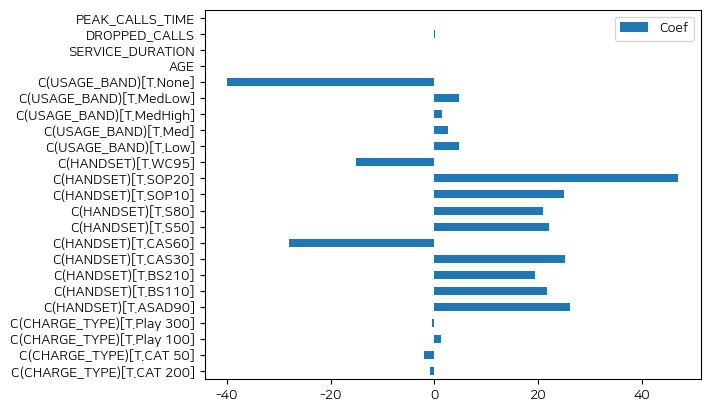

In [32]:
# 설명변수 중요도
df_logistic_coef = pd.DataFrame({"Coef": log_result.params.values[1:]}, index = log_model.exog_names[1:])
df_logistic_coef.plot.barh(y = "Coef")

## 결론 도출 

#### 표준화 회귀 계수

In [ ]:
# select_dtypes: 특정 변수 타입을 선택/제외하여 데이터 추출
df_char = df_raw.select_dtypes(include = "object")
df_numeric = df_raw.select_dtypes(exclude = "object")

# Data Scaling
scaler = StandardScaler()
np_numeric_scaled = scaler.fit_transform(df_numeric)
df_numeric_scaled = pd.DataFrame(np_numeric_scaled, columns = df_numeric.columns)

# 문자 데이터 + 숫자 데이터
df_scaled = pd.concat([df_numeric_scaled, df_char],axis = 1)

In [ ]:
# BAD 데이터를 0과 1로 변환, np.where(조건, 조건을 만족하는 경우, 만족하지 않는 경우)
df_scaled["CHURN"] = np.where(df_scaled["CHURN"]> 0, 1, 0)
df_scaled.head()

In [ ]:
# 데이터 분할
df_scaled_train, df_scaled_test = train_test_split(df_scaled, # 데이터
                                                   test_size = 0.3, # test 데이터의 비율
                                                   random_state = 1234)  # random state

In [ ]:
# from_formula 함수를 이용하여 변수 역할 지정
# scaled_log_model = Logit.from_formula("""CHURN ~ C(GENDER) + AGE + C(CHARGE_TYPE) + C(HANDSET) + C(USAGE_BAND) + SERVICE_DURATION +
#                                             DROPPED_CALLS + PEAK_CALLS_NO + PEAK_CALLS_TIME + WEEKEND_CALLS_NO + WEEKEND_CALLS_TIME +
#                                             TOTAL_CALLS_NO + TOTAL_CALLS_TIME""" , df_scaled_train)

# 선정된 설명변수 기준
scaled_log_model = Logit.from_formula("""CHURN ~ AGE + C(CHARGE_TYPE) + C(HANDSET) + C(USAGE_BAND) + SERVICE_DURATION +
                                DROPPED_CALLS + PEAK_CALLS_TIME """, df_scaled_train)


# 적합
scaled_log_result = scaled_log_model.fit()
# 결과 출력
print(scaled_log_result.summary())

In [ ]:
# 설명변수 중요도
df_logistic_coef = pd.DataFrame({"Coef": scaled_log_result.params.values[1:]}, index = scaled_log_model.exog_names[1:])
df_logistic_coef.plot.barh(y = "Coef")

# End of Code